In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_table("total_tads_histonesignal.txt",header=None)
df.columns = ["chr", "start", "end", "wt-k27ac_1", "wt-k27ac_2",'wt-4me3_1','wt-4me3_2','wt-27me3_1','wt-27me3_2', "wt-input_1", "wt-input_2", "pi-k27ac_1", "pi-k27ac_2",'pi-4me3_1','pi-4me3_2','pi-27me3_1','pi-27me3_2',"pi-input_1", "pi-input_2","TADs"]
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,wt-input_2,pi-k27ac_1,pi-k27ac_2,pi-4me3_1,pi-4me3_2,pi-27me3_1,pi-27me3_2,pi-input_1,pi-input_2,TADs
0,chr5,22240000,22520000,16833.0,22093.0,14594.0,13245.0,8186.0,9733.0,2763.0,2716.0,19145.0,31142.0,5470.0,25609.0,2982.0,5582.0,2000.0,2217.0,part_1_0-5
1,chr13,83200000,83440000,9567.0,10356.0,7488.0,6717.0,1308.0,1256.0,1234.0,1150.0,6226.0,9765.0,2554.0,11588.0,300.0,594.0,771.0,862.0,part_1_0-5
2,chr14,7360000,7560000,17392.0,18338.0,9598.0,8668.0,3192.0,3628.0,1968.0,1886.0,15134.0,23671.0,4169.0,19412.0,1072.0,2096.0,1204.0,1198.0,part_1_0-5
3,chr14,47920000,48160000,16157.0,17941.0,11498.0,10682.0,6342.0,6913.0,2261.0,2220.0,15177.0,22854.0,4216.0,19158.0,2213.0,3970.0,1585.0,1771.0,part_1_0-5
4,chr6,69640000,69960000,21757.0,26546.0,12799.0,11514.0,10934.0,13167.0,2882.0,3104.0,21796.0,32430.0,4435.0,20352.0,4471.0,8010.0,2186.0,2459.0,part_1_0-5


In [3]:
#calibrate depth
df["wt-k27ac_1nor"] = df["wt-k27ac_1"]/47
df["wt-k27ac_2nor"] = df["wt-k27ac_2"]/53
df["wt-4me3_1nor"] = df["wt-4me3_1"]/37
df["wt-4me3_2nor"] = df["wt-4me3_2"]/34
df["wt-k27me3_1nor"] = df["wt-27me3_1"]/63
df["wt-k27me3_2nor"] = df["wt-27me3_2"]/73
df["wt-igg_1nor"] = df["wt-input_1"]/10
df["wt-igg_2nor"] = df["wt-input_2"]/10
df["pi-k27ac_1nor"] = df["pi-k27ac_1"]/38
df["pi-k27ac_2nor"] = df["pi-k27ac_2"]/59
df["pi-4me3_1nor"] = df["pi-4me3_1"]/13
df["pi-4me3_2nor"] = df["pi-4me3_2"]/58
df["pi-k27me3_1nor"] = df["pi-27me3_1"]/26
df["pi-k27me3_2nor"] = df["pi-27me3_2"]/46
df["pi-igg_1nor"] = df["pi-input_1"]/8
df["pi-igg_2nor"] = df["pi-input_2"]/9
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,wt-igg_1nor,wt-igg_2nor,pi-k27ac_1nor,pi-k27ac_2nor,pi-4me3_1nor,pi-4me3_2nor,pi-k27me3_1nor,pi-k27me3_2nor,pi-igg_1nor,pi-igg_2nor
0,chr5,22240000,22520000,16833.0,22093.0,14594.0,13245.0,8186.0,9733.0,2763.0,...,276.3,271.6,503.815789,527.830508,420.769231,441.534483,114.692308,121.347826,250.000,246.333333
1,chr13,83200000,83440000,9567.0,10356.0,7488.0,6717.0,1308.0,1256.0,1234.0,...,123.4,115.0,163.842105,165.508475,196.461538,199.793103,11.538462,12.913043,96.375,95.777778
2,chr14,7360000,7560000,17392.0,18338.0,9598.0,8668.0,3192.0,3628.0,1968.0,...,196.8,188.6,398.263158,401.203390,320.692308,334.689655,41.230769,45.565217,150.500,133.111111
3,chr14,47920000,48160000,16157.0,17941.0,11498.0,10682.0,6342.0,6913.0,2261.0,...,226.1,222.0,399.394737,387.355932,324.307692,330.310345,85.115385,86.304348,198.125,196.777778
4,chr6,69640000,69960000,21757.0,26546.0,12799.0,11514.0,10934.0,13167.0,2882.0,...,288.2,310.4,573.578947,549.661017,341.153846,350.896552,171.961538,174.130435,273.250,273.222222


In [4]:
df['wt-k27ac_mean'] = df[['wt-k27ac_1nor', 'wt-k27ac_2nor']].mean(axis=1)
df['wt-4me3_mean'] = df[['wt-4me3_1nor', 'wt-4me3_2nor']].mean(axis=1)
df['wt-k27me3_mean'] = df[['wt-k27me3_1nor', 'wt-k27me3_2nor']].mean(axis=1)
df['wt-igg_mean'] = df[['wt-igg_1nor', 'wt-igg_2nor']].mean(axis=1)

In [5]:
df['pi-k27ac_mean'] = df[['pi-k27ac_1nor', 'pi-k27ac_2nor']].mean(axis=1)
df['pi-4me3_mean'] = df[['pi-4me3_1nor', 'pi-4me3_2nor']].mean(axis=1)
df['pi-k27me3_mean'] = df[['pi-k27me3_1nor', 'pi-k27me3_2nor']].mean(axis=1)
df['pi-igg_mean'] = df[['pi-igg_1nor', 'pi-igg_2nor']].mean(axis=1)

In [6]:
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,pi-igg_1nor,pi-igg_2nor,wt-k27ac_mean,wt-4me3_mean,wt-k27me3_mean,wt-igg_mean,pi-k27ac_mean,pi-4me3_mean,pi-k27me3_mean,pi-igg_mean
0,chr8,84700000,84800000,465.0,534.0,238.0,286.0,2274.0,2636.0,194.0,...,27.00,23.000000,9.984544,7.422099,36.102414,20.30,5.252899,7.348806,31.362876,25.000000
1,chr6,6400000,6500000,1545.0,1647.0,425.0,462.0,1211.0,1420.0,350.0,...,40.75,40.444444,31.973906,12.537361,19.337139,34.30,27.337422,11.523210,14.095318,40.597222
2,chr7,45600000,45700000,1275.0,1100.0,332.0,397.0,494.0,485.0,324.0,...,31.75,32.888889,23.941188,10.324722,7.242553,29.50,15.212979,6.456897,3.761706,32.319444
3,chr2,118500000,118600000,1207.0,1069.0,276.0,280.0,912.0,1011.0,213.0,...,26.50,23.333333,22.925331,7.847377,14.162753,23.15,13.522748,7.582228,10.668896,24.916667
4,chr9,133000000,133100000,999.0,964.0,582.0,592.0,8446.0,9524.0,495.0,...,61.75,62.555556,19.721999,16.570747,132.264623,48.25,13.500669,16.888594,125.006689,62.152778


In [6]:
df["wt-k27ac_change"] = np.log2((df["wt-k27ac_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["wt-4me3_change"] = np.log2((df["wt-4me3_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["wt-k27me3_change"] = np.log2((df["wt-k27me3_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["pi-k27ac_change"] = np.log2((df["pi-k27ac_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df["pi-4me3_change"] = np.log2((df["pi-4me3_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df["pi-k27me3_change"] = np.log2((df["pi-k27me3_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,pi-k27ac_mean,pi-4me3_mean,pi-k27me3_mean,pi-igg_mean,wt-k27ac_change,wt-4me3_change,wt-k27me3_change,pi-k27ac_change,pi-4me3_change,pi-k27me3_change
0,chr5,22240000,22520000,16833.0,22093.0,14594.0,13245.0,8186.0,9733.0,2763.0,...,515.823149,431.151857,118.020067,248.166667,0.500278,0.516923,-1.057390,1.055564,0.796884,-1.072271
1,chr13,83200000,83440000,9567.0,10356.0,7488.0,6717.0,1308.0,1256.0,1234.0,...,164.675290,198.127321,12.225753,96.076389,0.742817,0.746384,-2.650488,0.777364,1.044166,-2.974156
2,chr14,7360000,7560000,17392.0,18338.0,9598.0,8668.0,3192.0,3628.0,1968.0,...,399.733274,327.690981,43.397993,141.805556,0.893685,0.416382,-1.941075,1.495117,1.208416,-1.708191
3,chr14,47920000,48160000,16157.0,17941.0,11498.0,10682.0,6342.0,6913.0,2261.0,...,393.375335,327.309019,85.709866,197.451389,0.606531,0.479880,-1.197638,0.994405,0.729153,-1.203955
4,chr6,69640000,69960000,21757.0,26546.0,12799.0,11514.0,10934.0,13167.0,2882.0,...,561.619982,346.025199,173.045987,273.236111,0.687114,0.193597,-0.758144,1.039443,0.340728,-0.658990


In [7]:
df.loc[df['wt-k27ac_change'] < 0, 'wt-k27ac_change'] = 0
df.loc[df['wt-4me3_change'] < 0, 'wt-4me3_change'] = 0
df.loc[df['wt-k27me3_change'] < 0, 'wt-k27me3_change'] = 0
df.loc[df['pi-k27ac_change'] < 0, 'pi-k27ac_change'] = 0
df.loc[df['pi-4me3_change'] < 0, 'pi-4me3_change'] = 0
df.loc[df['pi-k27me3_change'] < 0, 'pi-k27me3_change'] = 0
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,pi-k27ac_mean,pi-4me3_mean,pi-k27me3_mean,pi-igg_mean,wt-k27ac_change,wt-4me3_change,wt-k27me3_change,pi-k27ac_change,pi-4me3_change,pi-k27me3_change
0,chr5,22240000,22520000,16833.0,22093.0,14594.0,13245.0,8186.0,9733.0,2763.0,...,515.823149,431.151857,118.020067,248.166667,0.500278,0.516923,0.0,1.055564,0.796884,0.0
1,chr13,83200000,83440000,9567.0,10356.0,7488.0,6717.0,1308.0,1256.0,1234.0,...,164.675290,198.127321,12.225753,96.076389,0.742817,0.746384,0.0,0.777364,1.044166,0.0
2,chr14,7360000,7560000,17392.0,18338.0,9598.0,8668.0,3192.0,3628.0,1968.0,...,399.733274,327.690981,43.397993,141.805556,0.893685,0.416382,0.0,1.495117,1.208416,0.0
3,chr14,47920000,48160000,16157.0,17941.0,11498.0,10682.0,6342.0,6913.0,2261.0,...,393.375335,327.309019,85.709866,197.451389,0.606531,0.479880,0.0,0.994405,0.729153,0.0
4,chr6,69640000,69960000,21757.0,26546.0,12799.0,11514.0,10934.0,13167.0,2882.0,...,561.619982,346.025199,173.045987,273.236111,0.687114,0.193597,0.0,1.039443,0.340728,0.0


In [8]:
h3k27ac = df[["chr","start","end","wt-k27ac_change","pi-k27ac_change","TADs"]] 
h3k27ac.head()
h3k27ac.to_csv("h3k27ac_change.txt", sep="\t", index=False)

In [9]:
h3k27me3 = df[["chr","start","end","wt-k27me3_change","pi-k27me3_change","TADs"]] 
h3k27me3.head()
h3k27me3.to_csv("h3k27me3_change.txt", sep="\t", index=False)

In [10]:
h3k4me3 = df[["chr","start","end","wt-4me3_change","pi-4me3_change","TADs"]] 
h3k4me3.head()
h3k4me3.to_csv("h3k4me3_change.txt", sep="\t", index=False)

In [22]:
df_filtered = h3k4me3[~((h3k4me3["wt-4me3_change"] == 0) & (h3k4me3["pi-4me3_change"] == 0))]

In [24]:
df_long = df_filtered.melt(
    id_vars=["chr", "start", "end", "TADs"],
    value_vars=["wt-4me3_change", "pi-4me3_change"],
    var_name="Group",
    value_name="Signal"
)

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

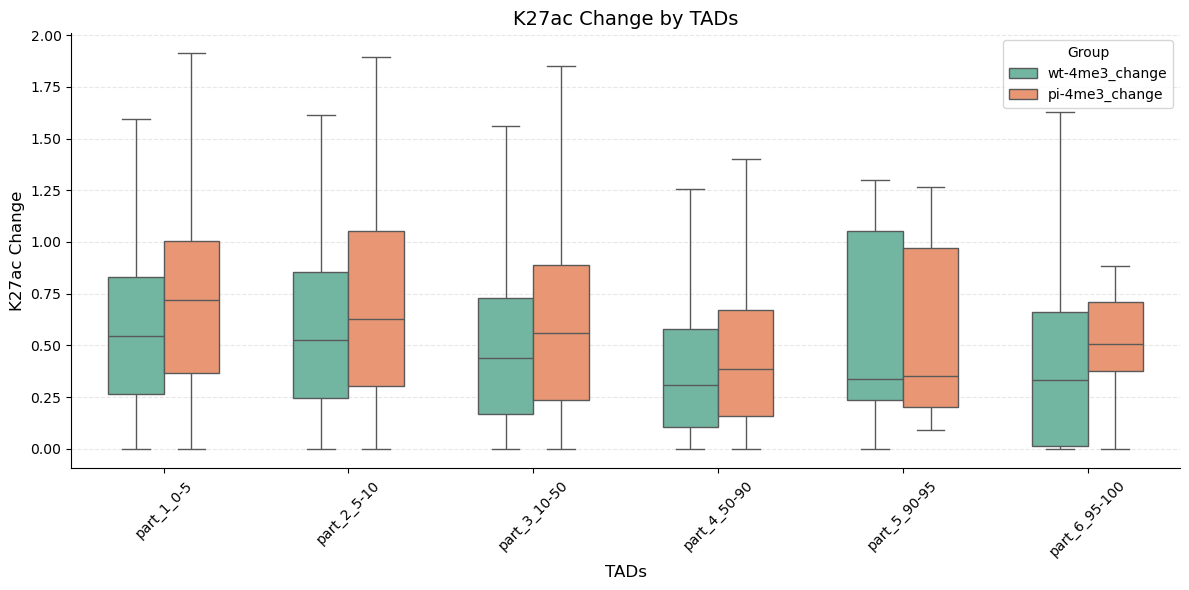

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="TADs",            # 按 TADs 分组
    y="Signal",          # Y轴是信号
    hue="Group",         # 区分 wt 和 pi
    data=df_long,
    palette="Set2",
    showfliers=False,    # 去掉离群点
    width=0.6
)

# 5. 美化图形
plt.title("K27ac Change by TADs", fontsize=14)
plt.xlabel("TADs", fontsize=12)
plt.ylabel("K27ac Change", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.legend(title="Group", loc="upper right")

# 6. 保存图片
plt.tight_layout()
#plt.savefig("k27ac_change_by_TADs_boxplot.png", dpi=300)
plt.show()

In [18]:
df = pd.read_table("h3k4me3_change.txt")
df.head()

,chr,start,end,wt-4me3_change,pi-4me3_change,TADs
0,chr5,22240000,22520000,0.516923,0.796884,part_1_0-5
1,chr13,83200000,83440000,0.746384,1.044166,part_1_0-5
2,chr14,7360000,7560000,0.416382,1.208416,part_1_0-5
3,chr14,47920000,48160000,0.479880,0.729153,part_1_0-5
4,chr6,69640000,69960000,0.193597,0.340728,part_1_0-5


In [19]:
df['change'] = df['pi-4me3_change']-df['wt-4me3_change']
df.head()

,chr,start,end,wt-4me3_change,pi-4me3_change,TADs,change
0,chr5,22240000,22520000,0.516923,0.796884,part_1_0-5,0.279961
1,chr13,83200000,83440000,0.746384,1.044166,part_1_0-5,0.297782
2,chr14,7360000,7560000,0.416382,1.208416,part_1_0-5,0.792034
3,chr14,47920000,48160000,0.479880,0.729153,part_1_0-5,0.249273
4,chr6,69640000,69960000,0.193597,0.340728,part_1_0-5,0.147131


In [20]:
df_filtered = df[~((df["wt-4me3_change"] == 0) & (df["pi-4me3_change"] == 0))]

In [4]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu, normaltest

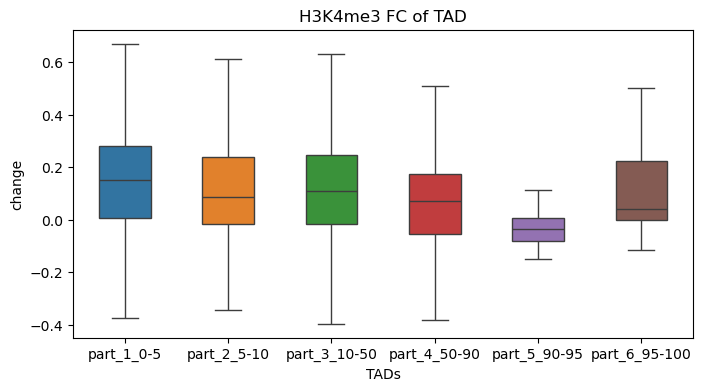

In [21]:
fig, ax = plt.subplots(figsize=(8,4))
ax = sns.boxplot(x='TADs', y='change', hue="TADs", data=df_filtered, showfliers=False,width=0.5)
plt.title("H3K4me3 FC of TAD")
plt.savefig("tad_4me3_change.pdf")
plt.show()